# A/B–тестирование нового способа оплаты на сайте

**Задача анализа:** протестировать эффективность нового способа оплаты на сайте

Описание структуры используемых данных в файле README проекта.

### Импорт библиотек

In [10]:
import pandas as pd
import scipy.stats as st
import pingouin as pg

### Импорт данных

In [11]:
df_groups = pd.read_csv('Проект_2_groups.csv')
df_checks = pd.read_csv('Проект_2_checks.csv')
df_active_studs = pd.read_csv('Проект_2_active_studs.csv')
df_group_add = pd.read_csv('Проект_2_group_add.csv')

### Предобработка данных

In [12]:
df_groups.head(2)

,id;grp
0,1489;B
1,1627;A


In [13]:
df_checks.head(2)

,"student_id;""rev"""
0,1627;990.0
1,3185;690.0


#### Разделение сдвоенных колонок с данными

In [14]:
# Разделил информацию о "id" и "grp" на две отдельные колонки в "df_groups"
df_groups[['id', 'grp']] = df_groups['id;grp'].str.split(';', n=1, expand=True)

# Разделил информацию о "student_id" и "rev" на две отдельные колонки в "df_checks"
df_checks[['student_id', 'rev']] = df_checks['student_id;"rev"'].str.split(';', n=1, expand=True)

#### Удаление лишних колонок

In [15]:
# Удалил лишнюю колонку в "df_groups"
df_groups = df_groups.drop(columns='id;grp')

df_groups.head(2)

,id,grp
0,1489,B
1,1627,A


In [16]:
# Удалил лишнюю колонку в "df_checks"
df_checks = df_checks.drop(columns='student_id;"rev"')

df_checks.head(2)

,student_id,rev
0,1627,990.0
1,3185,690.0


In [17]:
df_checks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   student_id  541 non-null    object
 1   rev         541 non-null    object
dtypes: object(2)
memory usage: 8.6+ KB


#### Изменение типов данных

In [18]:
# Изменил типы данных в колонках
df_checks['student_id'] = df_checks['student_id'].astype(int)
df_checks['rev'] = df_checks['rev'].astype(float)

In [12]:
df_checks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  541 non-null    int64  
 1   rev         541 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 8.6 KB


In [15]:
df_groups.shape

(74484, 2)

#### Проверка `id` пользователей на уникальность

In [25]:
# Проверил пользователей на уникальность по "id"
df_groups.id.nunique() # все уникальны

74484

In [17]:
df_group_add.head(2)

,id,grp
0,5694584,B
1,5694830,B


#### Добавление дополнительного объема данных

In [22]:
# Добавлены данные о пользователях, поступившие через 2 дня

df_gr = pd.concat([df_groups, df_group_add])
df_gr.shape

(74576, 2)

In [21]:
# Проверка пользователей на уникальность по "id"
df_gr.id.nunique() # все уникальны, число совпдаает с общим размером выборки

74576

In [23]:
df_gr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74576 entries, 0 to 91
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      74576 non-null  object
 1   grp     74576 non-null  object
dtypes: object(2)
memory usage: 1.7+ MB


In [24]:
# Изменил тип данных в колонке
df_gr['id'] = df_gr['id'].astype(int)

In [26]:
# Проверил данные об оплатах пользователей в дни проведения эксперимента
df_checks.shape

(541, 2)

In [27]:
# Проверил уникальность пользователей, которые что-либо оплачивали в дни проведения экспериментана по "student_id"
df_checks.student_id.nunique() # все уникальны

541

In [29]:
# Проверил данные о пользователях, которые зашли на платформу в дни проведения эксперимента (активные)
df_active_studs.shape

(8341, 1)

In [30]:
# Проверяю уникальность пользователей, которые зашли на платформу в дни проведения эксперимента по "student_id"
df_active_studs.student_id.nunique() # все уникальны

8341

In [31]:
df_active_studs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8341 entries, 0 to 8340
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  8341 non-null   int64
dtypes: int64(1)
memory usage: 65.3 KB


### Объединение данных

**Оставил только тех пользователей, которые заходили на платформу в дни проведения эксперимента, то есть активных.**

In [32]:
df_active = df_gr.merge(
    df_active_studs,
    left_on='id',
    right_on='student_id',
    how='inner'
)

In [33]:
df_active.shape

(8341, 3)

In [34]:
df_active.head(2)

,id,grp,student_id
0,1627,A,1627
1,2085,B,2085


In [35]:
# Удалил лишнюю колонку "student_id"
df_active.drop(columns='student_id', inplace=True)
df_active.head(2)

,id,grp
0,1627,A
1,2085,B


#### Добавление данных об оплатах пользователей в дни проведения эксперимента

In [36]:
# Добавил доп.данные об оплатах пользователей

df_full = df_active.merge(
    df_checks,
    left_on='id',
    right_on='student_id',
    how='left'
)

df_full.head(5)

,id,grp,student_id,rev
0,1627,A,1627.0,990.0
1,2085,B,NaN,NaN
2,2215,B,NaN,NaN
3,3391,A,NaN,NaN
4,3401,B,NaN,NaN


#### Подсчет количества активных пользователей, проводивших оплату во время эксперимента

In [38]:
# Количество активных пользователей, оплативших что-либо во время проведения эксперимента - 392
df_full.rev.count()

np.int64(392)

In [42]:
df_checks.rev.count()

np.int64(541)

### Проверка качества данных. Есть ли пользователи, совершившие оплату, но не входящие в число активных? Сколько таких?

In [43]:
# Разница
df_checks.rev.count() - df_full.rev.count()

np.int64(149)

#### Были обнаружены 149 пользователей, совершившие какую-либо оплату в приложении, но при этом отсутствующие среди активных  пользователей (заходивших на платформу). 

#### Это требует дополнительной проверки качества данных. Либо уточнения относительно возможности оплаты другими способами.

In [44]:
# Удалена лишняя колонка в "df_full"
df_full = df_full.drop(columns='student_id')

df_full.head(5)

,id,grp,rev
0,1627,A,990.0
1,2085,B,NaN
2,2215,B,NaN
3,3391,A,NaN
4,3401,B,NaN


In [45]:
# Заполнение пропусков на 0 - это те, кто не совершал оплату
df_full['rev'] = df_full['rev'].fillna(0)

In [46]:
# Проверка размера контрольной и экспериментальной групп
df_full.groupby('grp').size()

grp
A    1538
B    6803
dtype: int64

In [47]:
# Количество оплат в контрольной и экспериментальной группах
df_full.groupby('grp')['rev'].apply(lambda x: (x > 0).sum())

grp
A     78
B    314
Name: rev, dtype: int64

### Метрики

Были использованы следюущие метрики для анализа:

1. Конверсия в оплату (conversion rate). Новая механика касается процесса оплаты. С ее помощью проверю изменилась ли вероятность того, что активный пользователь вообще совершит оплату.

2. ARPPU - cредняя выручка с платящего пользователя. Сколько в среднем принес пользователь, который уже оплатил?

Данная метрика позволяет изолировать эффект изменения среднего чека от влияния конверсии, поскольку исключает неплатящих пользователей из анализа. В рамках данного датасета каждый пользователь совершал не более одной оплаты, поэтому ARPPU эквивалентен среднему чеку.

#### Проверка 1 гипотезы - CR

In [48]:
# Гипотеза 1 - Конверсия в покупку 
# Подсчет конверсии в оплату - доп.столбец с бинарными вариантами (1 - оплатил, 0 - не оплатил)

df_full['paid'] = (df_full['rev'] > 0).astype(int)
df_full.head()

,id,grp,rev,paid
0,1627,A,990.0,1
1,2085,B,0.0,0
2,2215,B,0.0,0
3,3391,A,0.0,0
4,3401,B,0.0,0


In [49]:
# Таблица сопряженности

contingency = pd.crosstab(df_full['grp'], df_full['paid'])
contingency

paid,0,1
grp,,
A,1460,78
B,6489,314


### Обоснование выбора метода проверки 1 гипотезы

Конверсия подсчитана в бинарном виде (0 - не оплатил, 1 - оплатил). Для сравнения долей в двух независимых группах был использован критерий χ² Пирсона.

Предпосылки применения критерия соблюдены:
- наблюдения независимы
- группы независимы
- ожидаемые частоты в каждой ячейке таблицы сопряженности не менее 5

In [50]:
# Статистика хи-квадрат

# Нулевая гипотеза: Стат.значимых различий в конверсии в оплату между контрольной и экспериментальной группой не обнаружено
# Альтернативная гипотеза: Есть стат.значимые различия в конверсии в оплату между контрольной и экспериментальной группой

st.chi2_contingency(contingency)

Chi2ContingencyResult(statistic=np.float64(0.48480826522557896), pvalue=np.float64(0.48625240457231045), dof=1, expected_freq=array([[1465.71897854,   72.28102146],
       [6483.28102146,  319.71897854]]))

Для проверки различий в конверсии между контрольной и экспериментальной группами был применен критерий χ² Пирсона.
По результатам теста получено:

χ² = 0.485;
p-value = 0.486.

Поскольку p-value значительно превышает уровень значимости 0.05, оснований отвергнуть нулевую гипотезу нет. Следовательно, статистически значимых различий в конверсии между контрольной и экспериментальной группами обнаружено не было.

### Проверка 2 гипотезы

In [52]:
# Гипотеза 2 - Средняя выручка с платящего пользователя (ARPPU)

# Отобраны только платящие пользователи
df_paid = df_full[df_full['rev'] > 0]
df_paid.head(5)

,id,grp,rev,paid
0,1627,A,990.0000,1
10,100300,B,990.0000,1
12,108270,B,290.0000,1
246,264473,B,1900.0001,1
279,274352,B,690.0000,1


In [54]:
# средние значения оплат в двух группах
df_paid.groupby('grp')['rev'].mean()

grp
A     933.589744
B    1257.878992
Name: rev, dtype: float64

### Проверка нормальности распределений

In [55]:
# Проверка нормальности распределений тестовой (B) и контрольной (A) групп

control = df_paid[df_paid['grp'] == 'A']['rev']
test = df_paid[df_paid['grp'] == 'B']['rev']

print(st.shapiro(control))
print(st.shapiro(test))

ShapiroResult(statistic=np.float64(0.7353236442181668), pvalue=np.float64(1.49869203824321e-10))
ShapiroResult(statistic=np.float64(0.8547218120137667), pvalue=np.float64(1.5433362141142128e-16))


### Результаты проверки нормальности

Перед выбором статистического критерия была проверена нормальность распределения ARPPU с помощью критерия Шапиро-Уилка.

Нулевая гипотеза: данные имеют нормальное распределение.

Альтернативная гипотеза: распределение отличается от нормального.

В обеих группах p-value значительно меньше уровня значимости 0,05, поэтому нулевая гипотеза отвергается. Следовательно, распределение выручки в обеих группах не является нормальным.

### Визуализация проверки нормальности распределений - QQ-plot

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

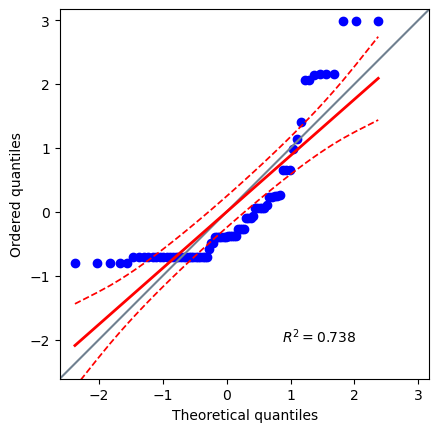

In [56]:
pg.qqplot(control)

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

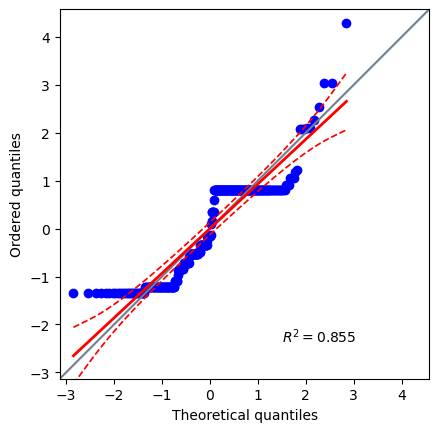

In [57]:
pg.qqplot(test)

#### Оба графика демонстрируют явную ассиметрию в распределениях

In [58]:
# Проверка равенства дисперсий с помощью теста Левена

st.levene(control, test)

LeveneResult(statistic=np.float64(3.075681699981606), pvalue=np.float64(0.08025675761347022))

### Результаты проверки равенства дисперсий

Для проверки равенства дисперсий был использован критерий Левена.

Нулевая гипотеза: дисперсии не различаются

Альтернативная гипотеза: дисперсии различаются.

Поскольку p-value > 0,05, оснований отвергнуть нулевую гипотезу нет.

In [59]:
# Нет необходимости использовать поправку на неравные дисперсии, был убран "equal_var=False", чтобы не считался t-тест Уэлча. 
# Далее проверена гипотеза о равенстве средних как через параметрический t-test (t-критерий Стьюдента), так и через 
# непараметрический тест Манна-Уитни (ранговый аналог t-теста)

# Проверка гипотезы о равенстве средних через t-test

st.ttest_ind(control, test)

TtestResult(statistic=np.float64(-3.1337795050930985), pvalue=np.float64(0.001856202526576587), df=np.float64(390.0))

Нулевая гипотеза предполагала равенство ARPPU (cредняя выручка с платящего пользователя) в контрольной и экспериментальной группах. По результатам теста получено:

t = -3.13
p-value = 0.001

Так как p-value < 0.05, нулевая гипотеза отвергается. Следовательно, различия в ARPPU между группами являются статистически значимыми.

Средний чек в экспериментальной группе выше, чем в контрольной.

Однако к результату этого теста стоит отнестись осторожно, так как изначальная предпосылка о нормальности распределений не соблюдена!

In [60]:
# Проверка гипотезы о равенстве распределений через тест Манна-Уитни

# Нулевая гипотеза: равенство распределений по всем характеристикам. 
# Альтернативная гипотеза: в какой-то из выборок чаще встречаются более высокие значения, чем в другой.

st.mannwhitneyu(control, test)

MannwhitneyuResult(statistic=np.float64(9001.0), pvalue=np.float64(0.0002511393831406922))

По результатам критерия Манна-Уитни получено:

U=9001,0; p-value=0,00025.

Поскольку p-value < 0,05, нулевая гипотеза отвергается. Следовательно, между контрольной и экспериментальной группами обнаружены статистически значимые различия в распределении ARPPU.

Но это говорит лишь о разнице в распределениях.

### Общий вывод по проведенному A/B тесту

В рамках эксперимента была протестирована новая механика оплаты, с целью оценки ее связи с поведением пользователей.

Анализ проводился по двум ключевым метрикам:

- конверсия в оплату (CR)
- средняя выручка на платящего пользователя (ARPPU)

Конверсия отражает долю пользователей, совершающих оплату, и позволяет оценить влияние механики на принятие решения о покупке. ARPPU, в свою очередь, характеризует средний чек среди платящих пользователей и позволяет оценить изменение глубины монетизации без влияния неплатящих пользователей.

При сравнении групп было обнаружено, что конверсия в оплату между контрольной и экспериментальной группами практически не различается: 5,07% в группе A и 4,62% в группе B. ARPPU в экспериментальной группе выше (1258 против 933 в контрольной). Таким образом, можно сделать вывод, что новая механика не связана с фактом совершения покупки, но потенциально увеличивает средний чек среди платящих пользователей. Статистический анализ показал, что различия в конверсии не являются значимыми (χ²-тест, p-value = 0,486). В то же время различия в ARPPU оказались статистически значимыми (p-value = 0,005), что позволяет отвергнуть гипотезу о равенстве средних чеков между группами. В экспериментальной группе средняя выручка на платящего пользователя значимо выше.

Однако, на мой взгляд, это **не позволяет принять решение о внедрении новой механики оплаты для всех**. Конверсия не изменилась, а рост ARPPU наблюдается **только среди относительно небольшой группы платящих пользователей**. Кроме того, распределение выручки является сильно неоднородным, что повышает чувствительность результата к отдельным крупным платежам. В совокупности это означает, что эффект по монетизации нельзя считать полностью устойчивым без дополнительной проверки.
